In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
!pip install yfinance

In [4]:
#The code fetches historical price data for Bitcoin, Ethereum, Tether, and Binance Coin for the past 5 years and keeps only the Close and Volume columns for each of these cryptocurrencies.
#This cleaned data can then be used for further analysis or machine learning tasks, such as predicting future prices.


btc = yf.Ticker('BTC-USD')
prices1 = btc.history(period='5y')
prices1.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

eth = yf.Ticker('ETH-USD')
prices2 = eth.history(period='5y')
prices2.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

usdt = yf.Ticker('USDT-USD')
prices3 = usdt.history(period='5y')
prices3.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

bnb = yf.Ticker('BNB-USD')
prices4 = bnb.history(period='5y')
prices4.drop(columns=['Open', 'High', 'Low', 'Dividends', 'Stock Splits'], axis = 1, inplace = True)

In [5]:
#The parameters lsuffix and rsuffix in the join method are used to add suffixes to overlapping column names when joining two DataFrames
# This is necessary to avoid column name conflicts when the two DataFrames have columns with the same name.

p1 = prices1.join(prices2, lsuffix = ' (BTC)', rsuffix = ' (ETH)')
p2 = prices3.join(prices4, lsuffix = ' (USDT)', rsuffix = ' (BNB)')
data = p1.join(p2, lsuffix = '_', rsuffix = '_')

In [6]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-03-14 00:00:00+00:00,59302.316406,43901225564,1854.564331,19344589211,0.999791,83527066354,264.636749,2044273970
2021-03-15 00:00:00+00:00,55907.199219,66419369890,1791.702271,26244738810,1.000374,110958014435,254.660828,2488528410
2021-03-16 00:00:00+00:00,56804.902344,59749798599,1806.971802,23828509590,1.000058,101176062799,258.100677,2425543830
2021-03-17 00:00:00+00:00,58870.894531,60258313191,1823.449341,24512917348,0.999083,94297363539,269.854858,2271426252
2021-03-18 00:00:00+00:00,57858.921875,55746041000,1782.855103,23263845504,1.000925,87360030730,261.704803,2445995134


In [7]:
data.head()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,,
2021-03-14 00:00:00+00:00,59302.316406,43901225564,1854.564331,19344589211,0.999791,83527066354,264.636749,2044273970
2021-03-15 00:00:00+00:00,55907.199219,66419369890,1791.702271,26244738810,1.000374,110958014435,254.660828,2488528410
2021-03-16 00:00:00+00:00,56804.902344,59749798599,1806.971802,23828509590,1.000058,101176062799,258.100677,2425543830
2021-03-17 00:00:00+00:00,58870.894531,60258313191,1823.449341,24512917348,0.999083,94297363539,269.854858,2271426252
2021-03-18 00:00:00+00:00,57858.921875,55746041000,1782.855103,23263845504,1.000925,87360030730,261.704803,2445995134


In [8]:
data.shape

(1827, 8)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1827 entries, 2021-03-14 00:00:00+00:00 to 2026-03-14 00:00:00+00:00
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Close (BTC)    1827 non-null   float64
 1   Volume (BTC)   1827 non-null   int64  
 2   Close (ETH)    1827 non-null   float64
 3   Volume (ETH)   1827 non-null   int64  
 4   Close (USDT)   1827 non-null   float64
 5   Volume (USDT)  1827 non-null   int64  
 6   Close (BNB)    1827 non-null   float64
 7   Volume (BNB)   1827 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 128.5 KB


In [10]:
data.isna().sum()

Close (BTC)      0
Volume (BTC)     0
Close (ETH)      0
Volume (ETH)     0
Close (USDT)     0
Volume (USDT)    0
Close (BNB)      0
Volume (BNB)     0
dtype: int64

In [11]:
data.describe()

,Close (BTC),Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
count,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03,1827.000000,1.827000e+03
mean,55841.632484,3.619389e+10,2573.438697,1.916636e+10,1.000099,7.006824e+10,481.669410,1.815258e+09
std,29741.033911,2.118585e+10,891.042224,1.268484e+10,0.000713,4.454860e+10,217.930770,1.337010e+09
min,15787.284180,5.331173e+09,993.636780,2.081626e+09,0.995872,9.989859e+09,197.042999,2.038465e+08
25%,29412.204102,2.112790e+10,1823.845398,1.017214e+10,0.999846,4.007070e+10,299.780624,9.409490e+08
50%,48628.511719,3.160472e+10,2502.349609,1.631720e+10,1.000122,6.007752e+10,430.246155,1.617928e+09
75%,72870.097656,4.538469e+10,3243.557007,2.385281e+10,1.000355,8.645823e+10,613.987274,2.189487e+09
max,124752.531250,1.817464e+11,4831.348633,9.773662e+10,1.011530,3.443980e+11,1310.214355,1.443632e+10


# EDA

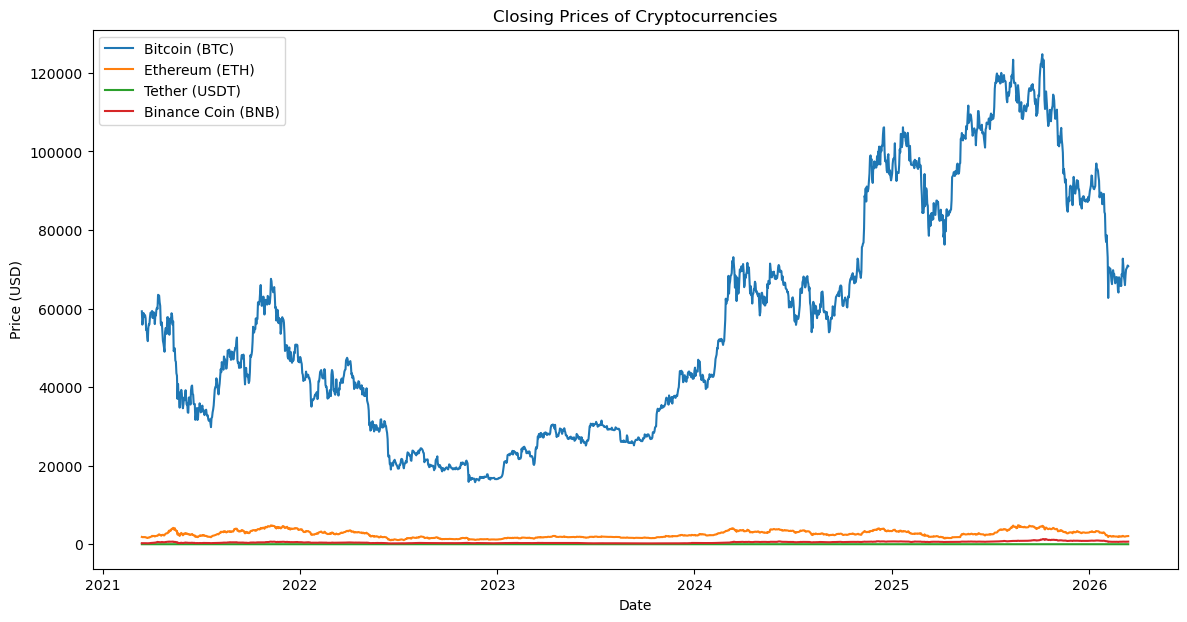

In [12]:
#Visualize the Closing Prices
# create a line plot to visualize the closing prices of all four cryptocurrencies over time:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Close (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Close (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Close (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Close (BNB)'], label='Binance Coin (BNB)')
plt.title('Closing Prices of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()


<Axes: xlabel='Date'>

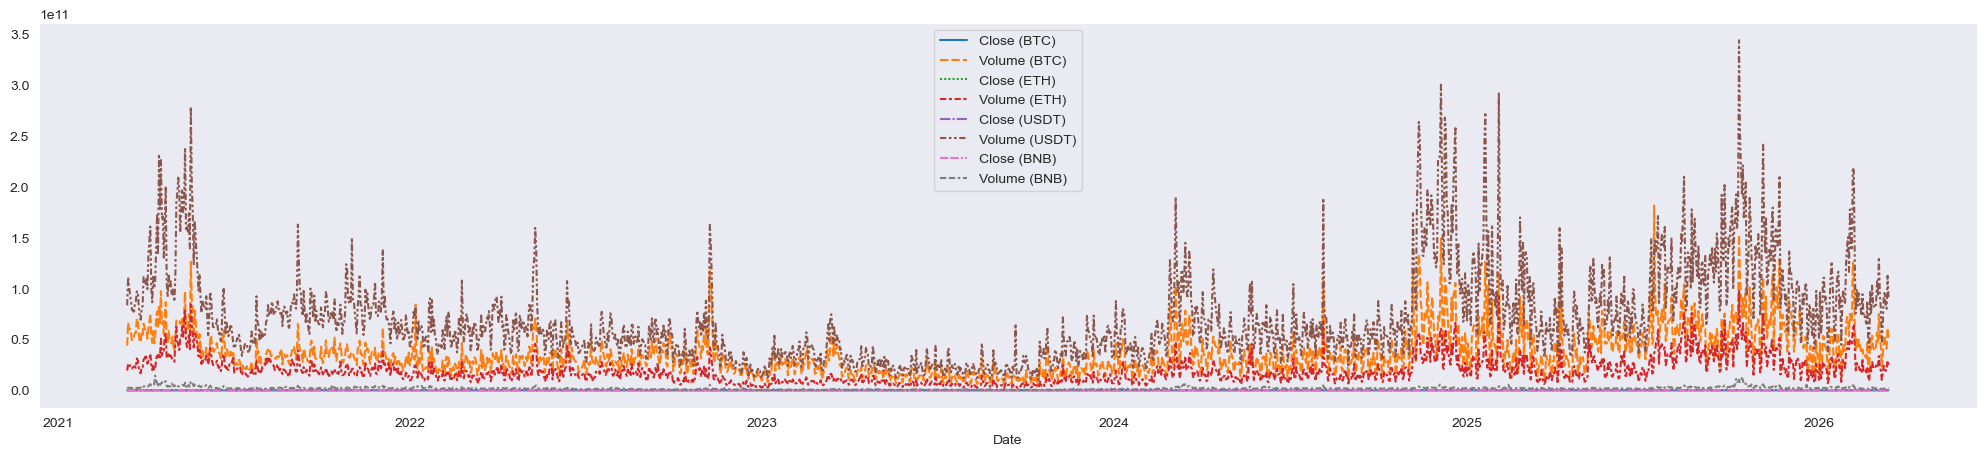

In [13]:
plt.figure(figsize=(25,5))
sns.set_style('dark')
sns.lineplot(data=data)

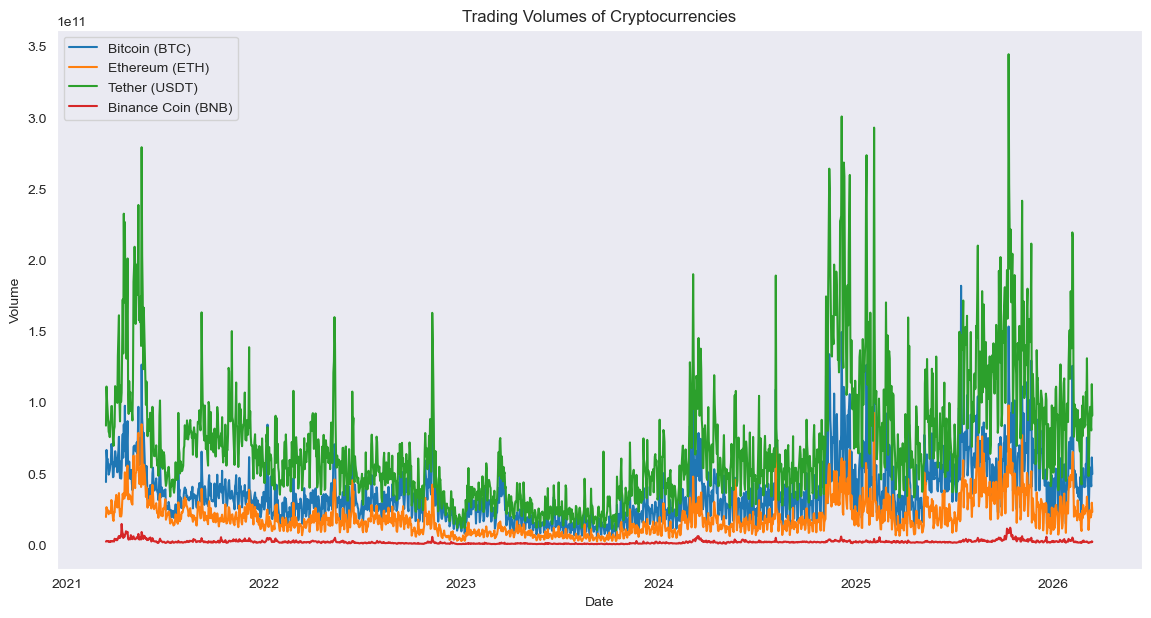

In [14]:
# Visualize the Trading Volumes
#Let's visualize the trading volumes of all four cryptocurrencies:
plt.figure(figsize=(14, 7))
plt.plot(data.index, data['Volume (BTC)'], label='Bitcoin (BTC)')
plt.plot(data.index, data['Volume (ETH)'], label='Ethereum (ETH)')
plt.plot(data.index, data['Volume (USDT)'], label='Tether (USDT)')
plt.plot(data.index, data['Volume (BNB)'], label='Binance Coin (BNB)')
plt.title('Trading Volumes of Cryptocurrencies')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.legend()
plt.show()


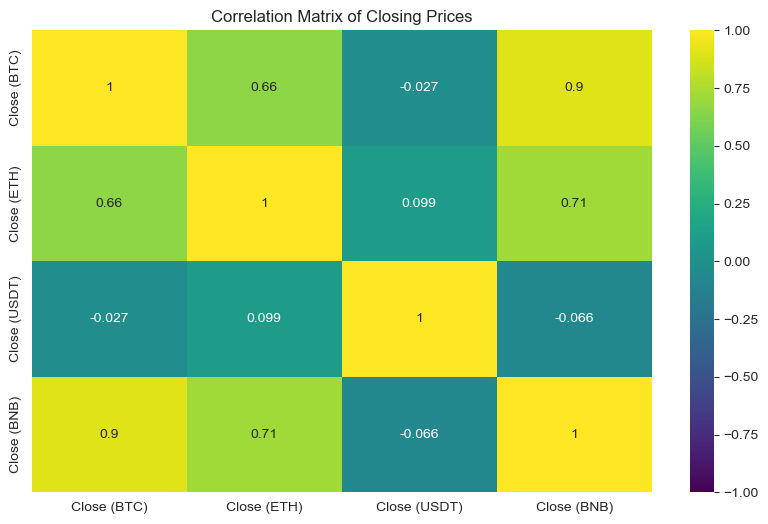

In [15]:
 #Correlation Analysis
#We'll analyze the correlation between the closing prices of the cryptocurrencies:
# Calculate the correlation matrix
corr_matrix = data[['Close (BTC)', 'Close (ETH)', 'Close (USDT)', 'Close (BNB)']].corr()

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='viridis', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Closing Prices')
plt.show()


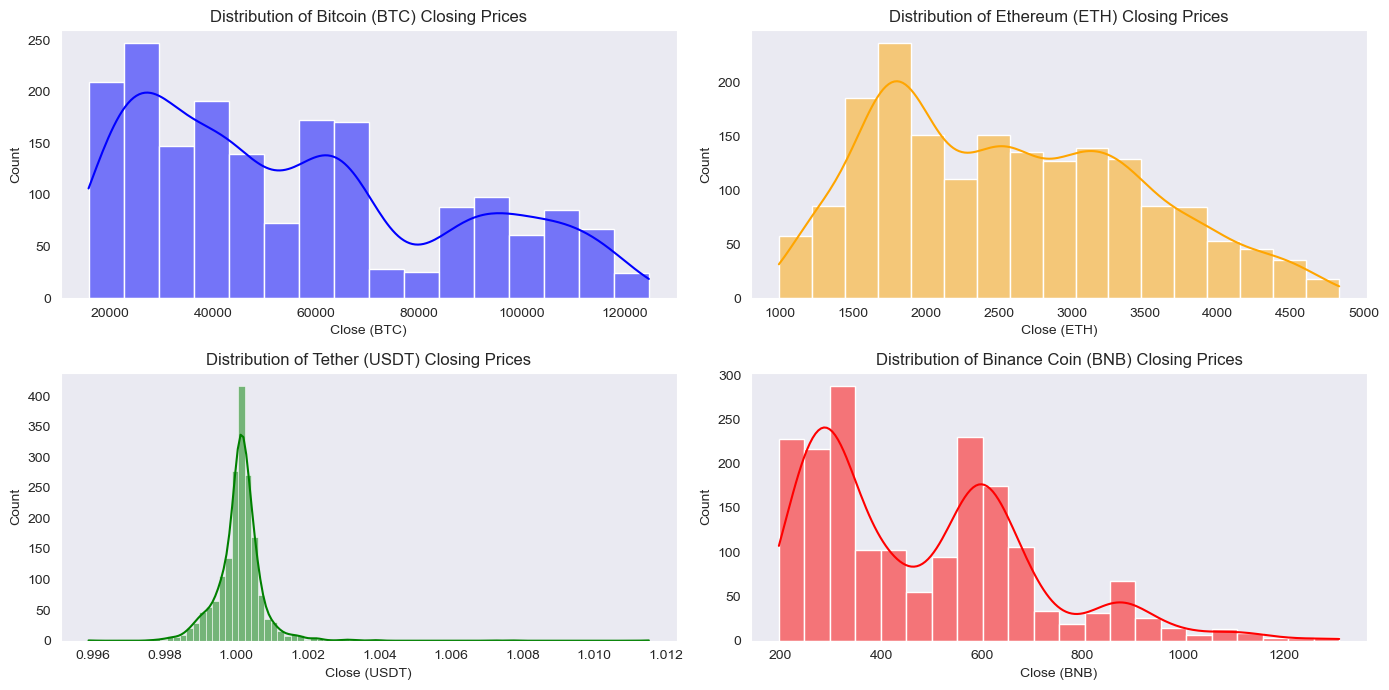

In [16]:
# Distribution of Closing Prices
#Let's plot the distribution of closing prices for each cryptocurrency:
plt.figure(figsize=(14, 7))

plt.subplot(2, 2, 1)
sns.histplot(data['Close (BTC)'], kde=True, color='blue')
plt.title('Distribution of Bitcoin (BTC) Closing Prices')

plt.subplot(2, 2, 2)
sns.histplot(data['Close (ETH)'], kde=True, color='orange')
plt.title('Distribution of Ethereum (ETH) Closing Prices')

plt.subplot(2, 2, 3)
sns.histplot(data['Close (USDT)'], kde=True, color='green')
plt.title('Distribution of Tether (USDT) Closing Prices')

plt.subplot(2, 2, 4)
sns.histplot(data['Close (BNB)'], kde=True, color='red')
plt.title('Distribution of Binance Coin (BNB) Closing Prices')

plt.tight_layout()
plt.show()


array([[<Axes: title={'center': 'Close (BTC)'}>,
        <Axes: title={'center': 'Volume (BTC)'}>,
        <Axes: title={'center': 'Close (ETH)'}>,
        <Axes: title={'center': 'Volume (ETH)'}>],
       [<Axes: title={'center': 'Close (USDT)'}>,
        <Axes: title={'center': 'Volume (USDT)'}>,
        <Axes: title={'center': 'Close (BNB)'}>,
        <Axes: title={'center': 'Volume (BNB)'}>]], dtype=object)

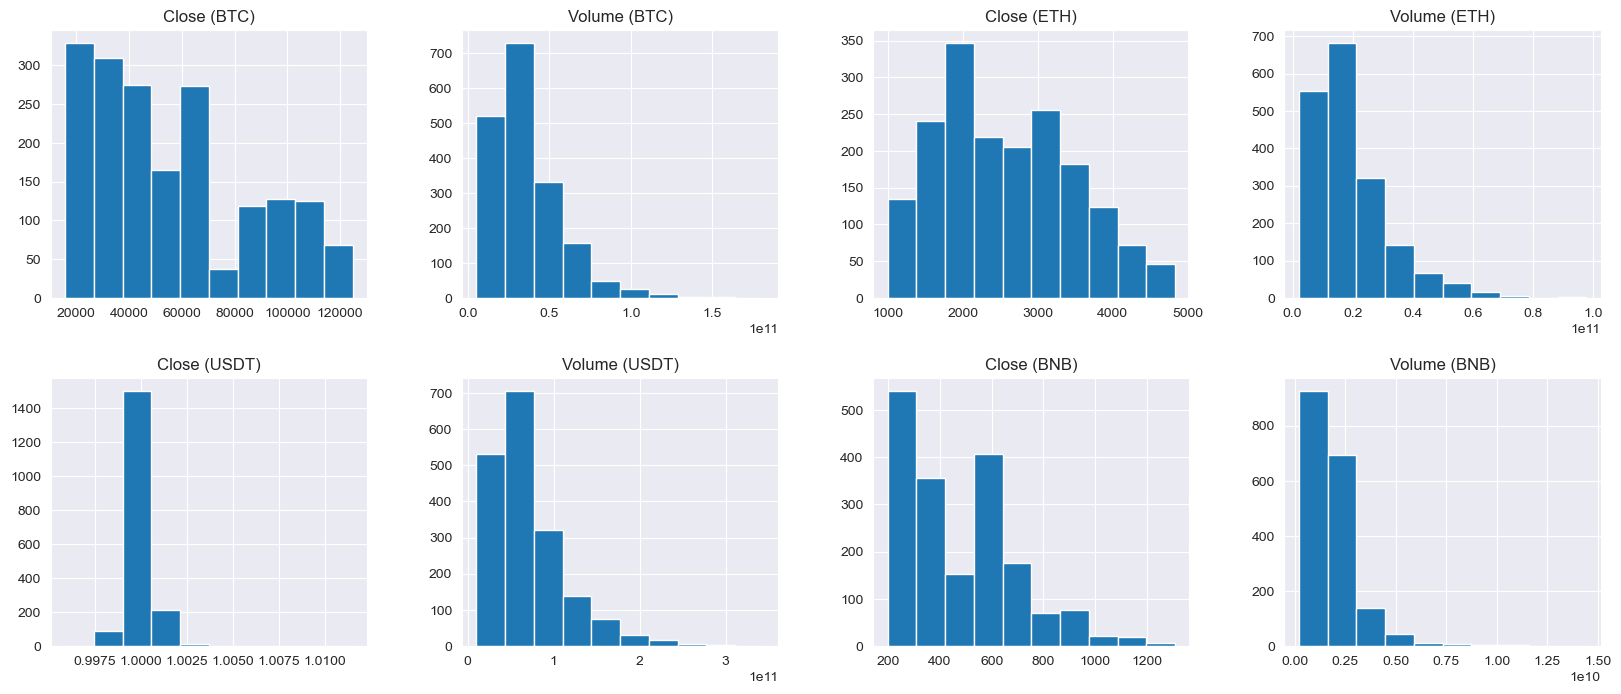

In [17]:
data.hist(figsize=(20, 8), layout=(2, 4))

array([[<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>],
       [<Axes: ylabel='Density'>, <Axes: ylabel='Density'>,
        <Axes: ylabel='Density'>, <Axes: ylabel='Density'>]], dtype=object)

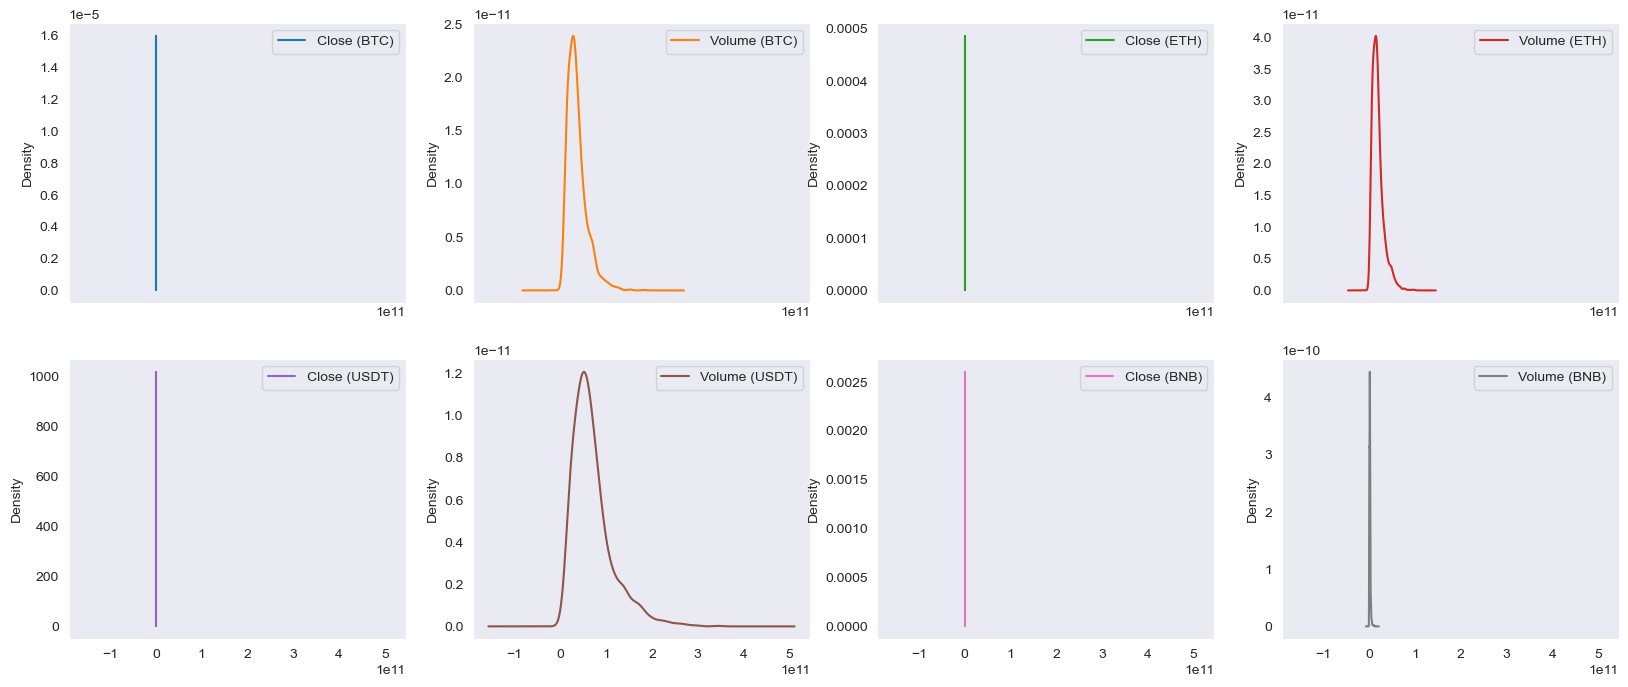

In [18]:
data.plot(kind = "kde", subplots = True, layout = (2, 4), figsize = (20, 8))

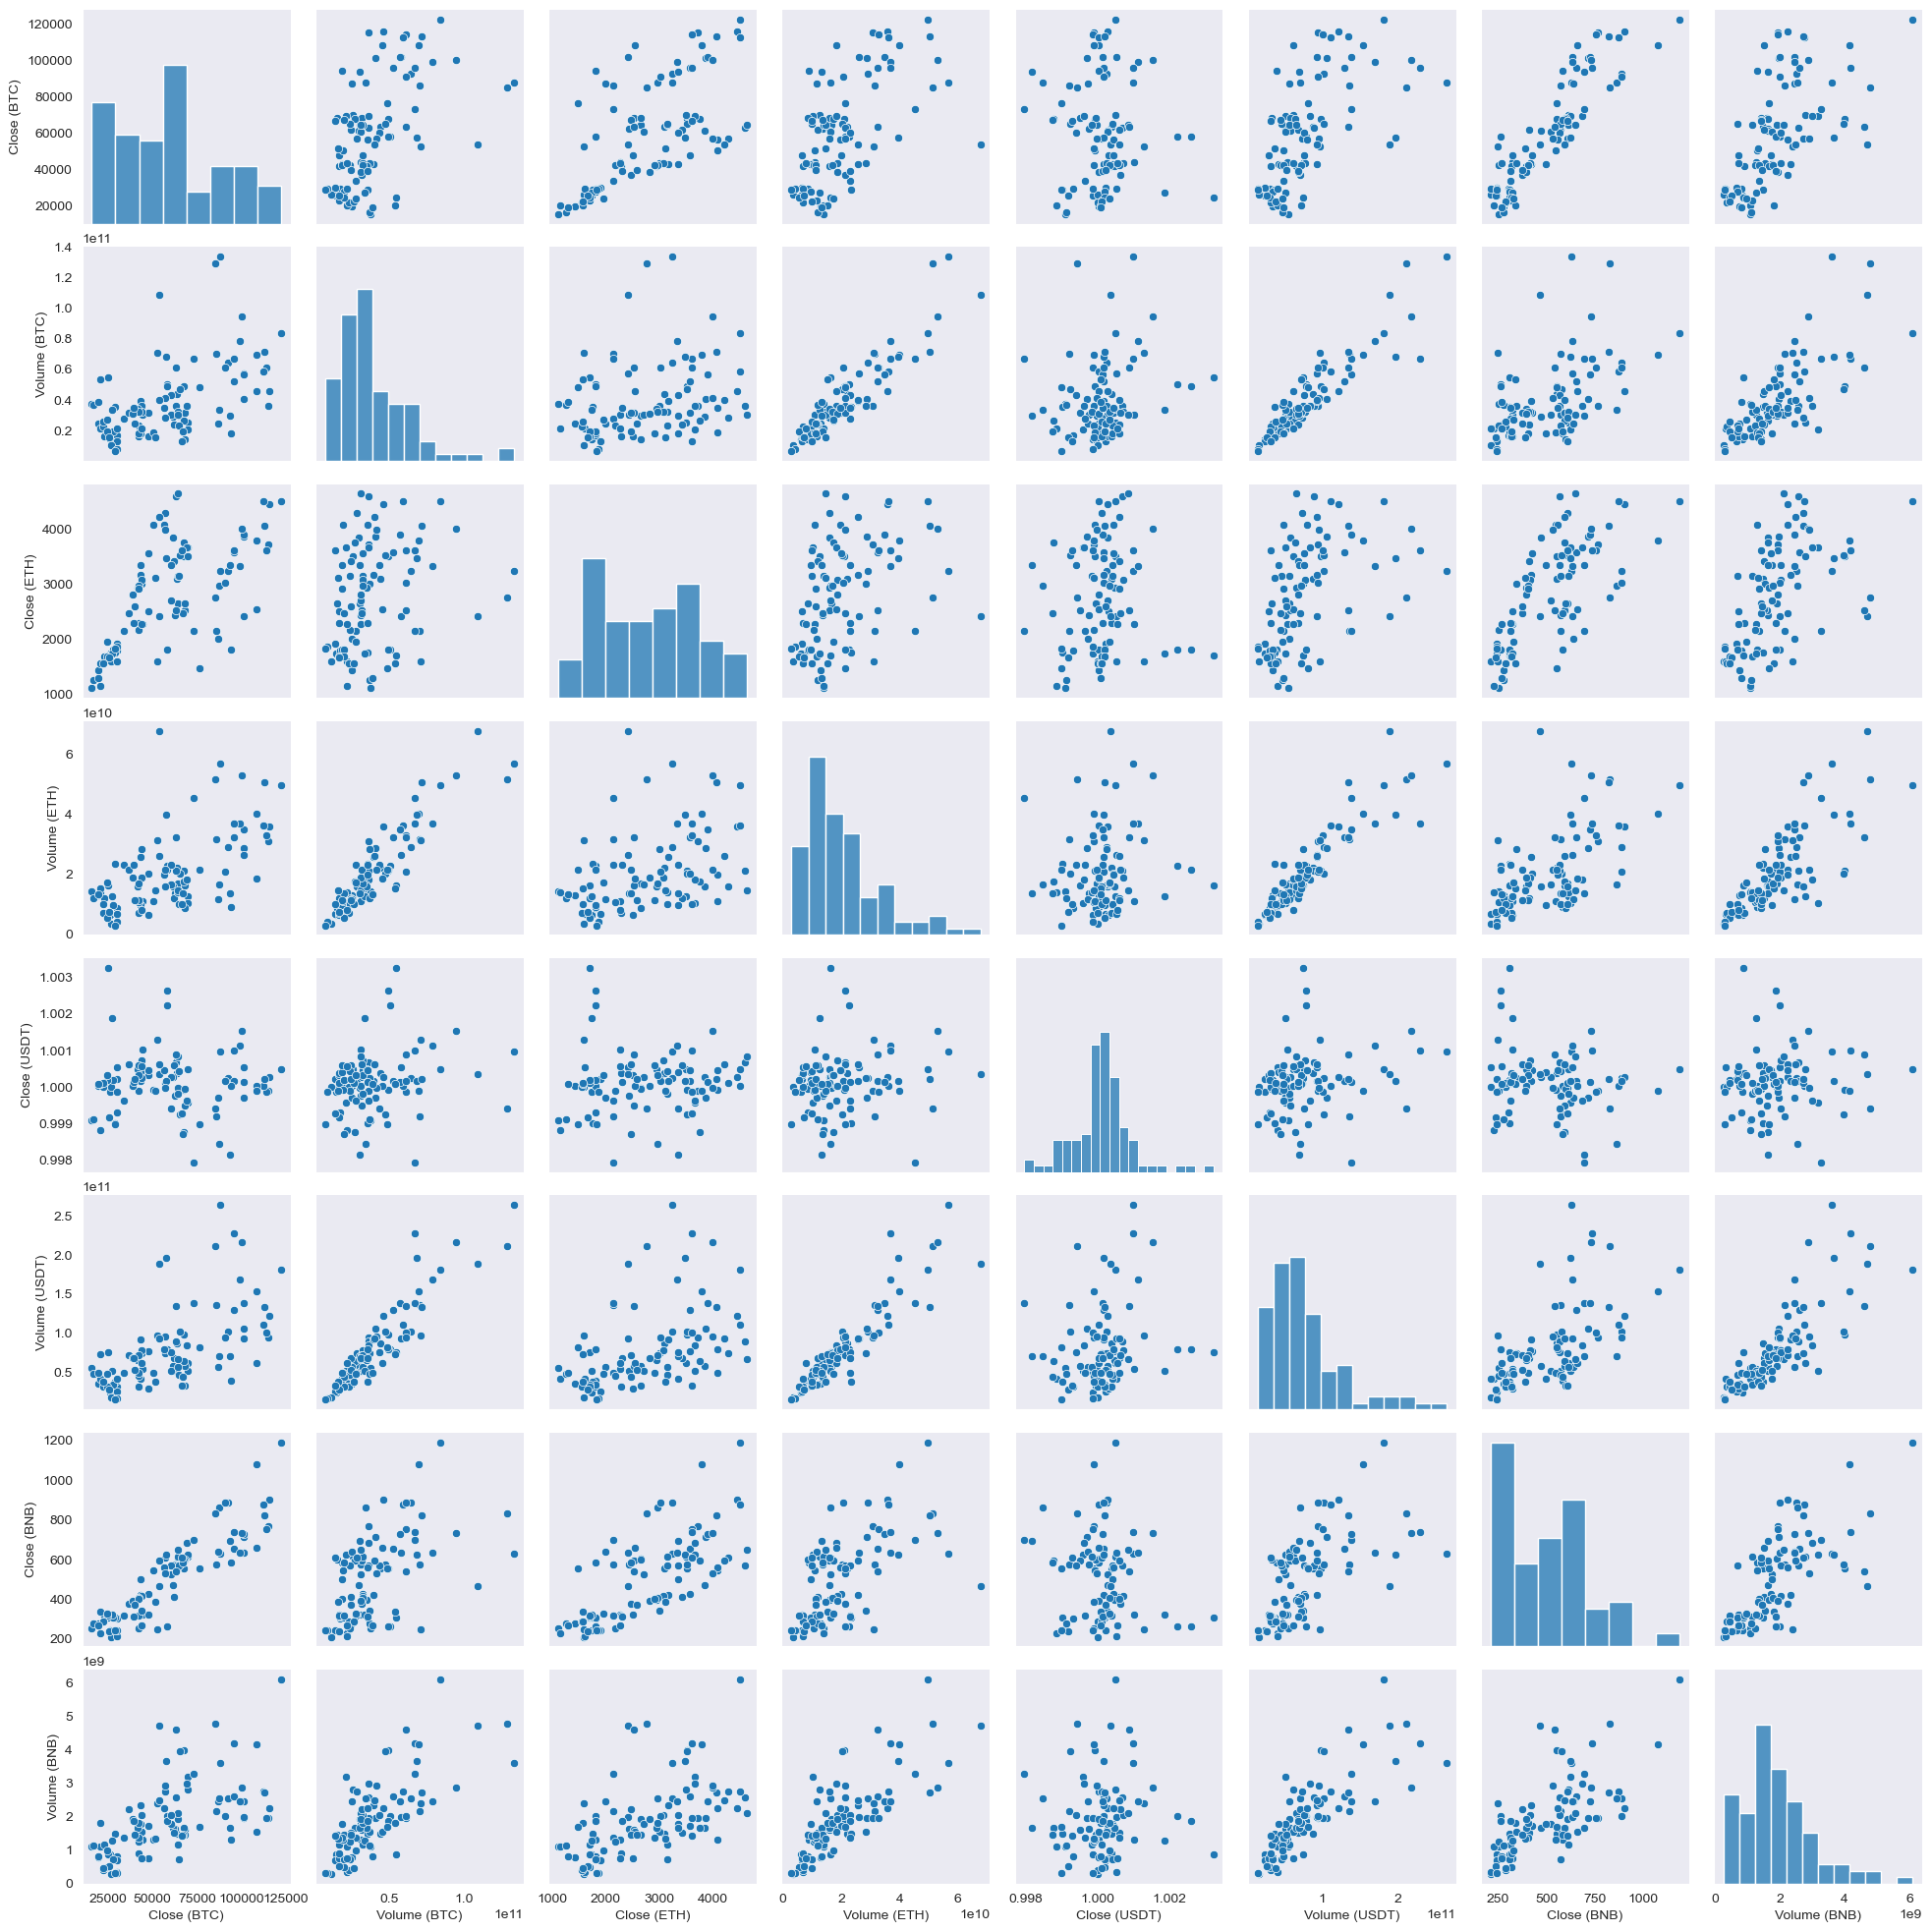

In [19]:

sns.pairplot(data.sample(n=100))

# Data Pre-Processing

In [20]:
X = data.drop(columns = ['Close (BTC)'], axis = 1)
Y = data.loc[:, 'Close (BTC)']

In [21]:
X.head()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2021-03-14 00:00:00+00:00,43901225564,1854.564331,19344589211,0.999791,83527066354,264.636749,2044273970
2021-03-15 00:00:00+00:00,66419369890,1791.702271,26244738810,1.000374,110958014435,254.660828,2488528410
2021-03-16 00:00:00+00:00,59749798599,1806.971802,23828509590,1.000058,101176062799,258.100677,2425543830
2021-03-17 00:00:00+00:00,60258313191,1823.449341,24512917348,0.999083,94297363539,269.854858,2271426252
2021-03-18 00:00:00+00:00,55746041000,1782.855103,23263845504,1.000925,87360030730,261.704803,2445995134


In [22]:
X.tail()

,Volume (BTC),Close (ETH),Volume (ETH),Close (USDT),Volume (USDT),Close (BNB),Volume (BNB)
Date,,,,,,,
2026-03-10 00:00:00+00:00,54003996096,2037.120483,23552353781,1.000115,96697987753,641.879211,1580638205
2026-03-11 00:00:00+00:00,45236859848,2051.573242,19031715359,1.000189,84262268074,651.478333,1616600713
2026-03-12 00:00:00+00:00,40871848129,2073.136230,20624954899,1.000050,80128786072,652.135010,1564250832
2026-03-13 00:00:00+00:00,61167226505,2092.563477,29345212033,1.000124,112624310318,655.881958,2275392491
2026-03-14 00:00:00+00:00,49502445568,2077.062256,22897651712,1.000160,90664435712,653.848877,1929143808


In [23]:
Y.head()


Date
2021-03-14 00:00:00+00:00    59302.316406
2021-03-15 00:00:00+00:00    55907.199219
2021-03-16 00:00:00+00:00    56804.902344
2021-03-17 00:00:00+00:00    58870.894531
2021-03-18 00:00:00+00:00    57858.921875
Name: Close (BTC), dtype: float64

In [24]:
# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [25]:
# Print the shapes of the resulting datasets
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {Y_train.shape}')
print(f'y_test shape: {Y_test.shape}')

X_train shape: (1461, 7)
X_test shape: (366, 7)
y_train shape: (1461,)
y_test shape: (366,)


In [26]:
#SelectKBest
#SelectKBest is a feature selection method provided by scikit-learn (sklearn) that selects the top k features based on a specified scoring function.
#This function evaluates each feature independently and selects those that have the strongest relationship with the target variable.

#Parameters
#k: Specifies the number of top features to select. In your case, k=4 indicates that you want to select the top 4 features

from sklearn.feature_selection import SelectKBest

fs = SelectKBest(k=4)
X_train = fs.fit_transform(X_train, Y_train)
X_test = fs.transform(X_test)

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:107: RuntimeWarning: invalid value encountered in divide
  msw = sswn / float(dfwn)


In [27]:
mask = fs.get_support()
selected_features = X.columns[mask]
print("Selected Features:", selected_features) 

Selected Features: Index(['Close (USDT)', 'Volume (USDT)', 'Close (BNB)', 'Volume (BNB)'], dtype='object')


In [28]:
X_train

array([[1.00088203e+00, 6.98315530e+10, 5.71648987e+02, 2.13295530e+09],
       [1.00079095e+00, 1.24069805e+11, 4.49007996e+02, 2.34009114e+09],
       [9.99101996e-01, 2.32884391e+10, 2.72397675e+02, 5.51451228e+08],
       ...,
       [1.00097799e+00, 1.92241730e+11, 9.93014038e+02, 4.89290326e+09],
       [1.00004995e+00, 3.90151659e+10, 2.75135376e+02, 8.18302597e+08],
       [1.00018203e+00, 3.46580585e+10, 3.08123108e+02, 4.84897937e+08]],
      shape=(1461, 4))

In [29]:
#MinMaxScaler is a preprocessing method in scikit-learn that transforms features by scaling them to a specified range.
# It's often used when your data needs to be normalized within a specific range to ensure all features contribute equally to the analysis.
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# implementation of 10 different regression algorithms using scikit-learn. Each algorithm is trained and evaluated on a sample dataset:

#Import Libraries and Generate Sample Data

from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

----- Linear Regression -----
Mean Squared Error (MSE): 147737705.44061235
R-squared: 0.8267020560640999

----- Ridge Regression -----
Mean Squared Error (MSE): 146593718.7213813
R-squared: 0.8280439649948055

----- Lasso Regression -----
Mean Squared Error (MSE): 147691601.5891368
R-squared: 0.8267561363860082

----- ElasticNet Regression -----
Mean Squared Error (MSE): 723061695.6520398
R-squared: 0.1518407246031428

----- Support Vector Regression (SVR) -----
Mean Squared Error (MSE): 883716378.0124291
R-squared: -0.03660897450174949

----- Decision Tree Regression -----
Mean Squared Error (MSE): 104834913.06531091
R-squared: 0.8770275006455934

----- Random Forest Regression -----
Mean Squared Error (MSE): 66956709.01464865
R-squared: 0.9214590481803758

----- Gradient Boosting Regression -----
Mean Squared Error (MSE): 80911849.74230614
R-squared: 0.9050895155128245

----- K-Nearest Neighbors Regression -----
Mean Squared Error (MSE): 73793160.00878812
R-squared: 0.913439816410330

c:\Users\USER\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


----- Neural Network Regression (MLP) -----
Mean Squared Error (MSE): 658097282.1798067
R-squared: 0.22804469196654042

                             Model           MSE  R-squared
0                Linear Regression  1.477377e+08   0.826702
1                 Ridge Regression  1.465937e+08   0.828044
2                 Lasso Regression  1.476916e+08   0.826756
3            ElasticNet Regression  7.230617e+08   0.151841
4  Support Vector Regression (SVR)  8.837164e+08  -0.036609
5         Decision Tree Regression  1.048349e+08   0.877028
6         Random Forest Regression  6.695671e+07   0.921459
7     Gradient Boosting Regression  8.091185e+07   0.905090
8   K-Nearest Neighbors Regression  7.379316e+07   0.913440
9  Neural Network Regression (MLP)  6.580973e+08   0.228045


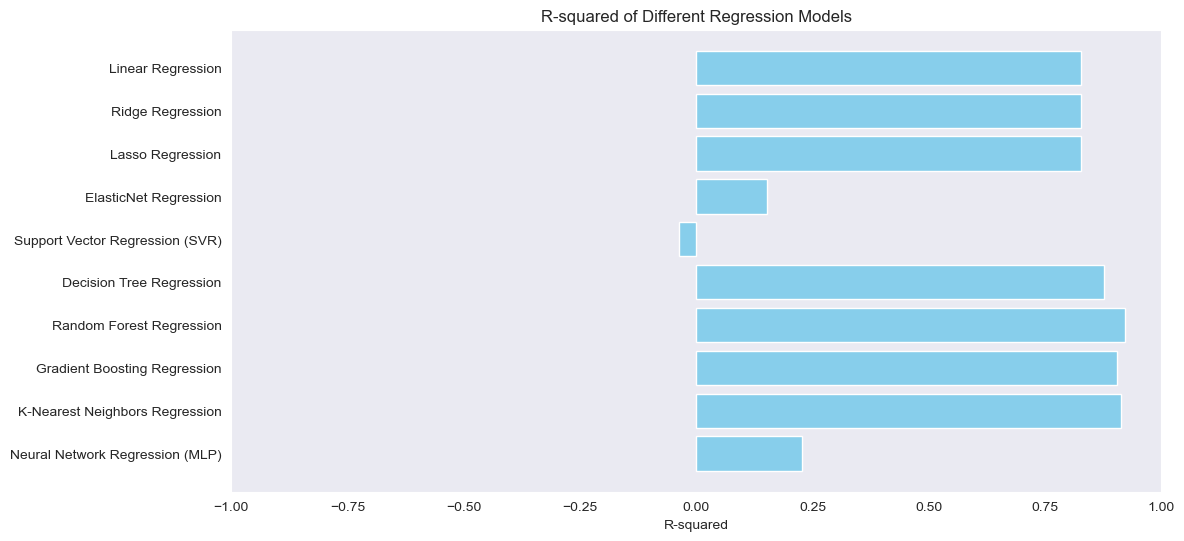

In [31]:

#Define Models and Perform Training and Evaluation
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'ElasticNet Regression': ElasticNet(alpha=1.0, l1_ratio=0.5),
    'Support Vector Regression (SVR)': SVR(kernel='rbf'),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting Regression': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1),
    'K-Nearest Neighbors Regression': KNeighborsRegressor(n_neighbors=5),
    'Neural Network Regression (MLP)': MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam')
}

# Train and evaluate each model
results = {'Model': [], 'MSE': [], 'R-squared': []}

for name, model in models.items():
    # Train the model
    model.fit(X_train, Y_train)

    # Predict on test set
    Y_pred = model.predict(X_test)

    # Evaluate model
    mse = mean_squared_error(Y_test, Y_pred)
    r2 = r2_score(Y_test, Y_pred)

    # Store results
    results['Model'].append(name)
    results['MSE'].append(mse)
    results['R-squared'].append(r2)

    # Print results
    print(f"----- {name} -----")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"R-squared: {r2}")
    print()

# Convert results to DataFrame for visualization
results_df = pd.DataFrame(results)
print(results_df)

# Plotting the results
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['R-squared'], color='skyblue')
plt.xlabel('R-squared')
plt.title('R-squared of Different Regression Models')
plt.xlim(-1, 1)
plt.gca().invert_yaxis()
plt.show()


In [32]:
import pickle
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

# Generate sample data
X, Y = make_regression(n_samples=1000, n_features=10, noise=0.1, random_state=0)


# Scale the features (optional but recommended for some algorithms)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize Random Forest Regressor
model_rf = RandomForestRegressor(n_estimators=100, random_state=0)

# Train the model
model_rf.fit(X_train, Y_train)

# Save the model to a file
filename = 'random_forest_model.pkl'
pickle.dump(model_rf, open(filename, 'wb'))

# Save scaler to a file
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Load the model from the file
loaded_model = pickle.load(open(filename, 'rb'))

# Predict using the loaded model
Y_pred = loaded_model.predict(X_test)

# Evaluate the loaded model
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Loaded Random Forest Regression - Mean Squared Error (MSE): {mse}")
print(f"Loaded Random Forest Regression - R-squared: {r2}")


Loaded Random Forest Regression - Mean Squared Error (MSE): 67134985.41679557
Loaded Random Forest Regression - R-squared: 0.9212499280112747
